In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\customer_segmentation_300_records.csv")

print(df.head())

   customer_id  age  gender  annual_income  spending_score  total_purchases
0            1   56  Female         117856              57               25
1            2   46    Male          58304              17               17
2            3   32  Female          89449              47               66
3            4   60    Male         102986              23               78
4            5   25  Female         109643              79               53


In [3]:
df.shape

(300, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      300 non-null    int64 
 1   age              300 non-null    int64 
 2   gender           300 non-null    object
 3   annual_income    300 non-null    int64 
 4   spending_score   300 non-null    int64 
 5   total_purchases  300 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 14.2+ KB


In [5]:
df.describe()

,customer_id,age,annual_income,spending_score,total_purchases
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,40.810000,67596.373333,49.113333,39.050000
std,86.746758,13.547164,28285.720904,29.691961,21.791828
min,1.000000,18.000000,20384.000000,1.000000,1.000000
25%,75.750000,29.000000,43773.250000,23.000000,22.000000
50%,150.500000,41.500000,64646.500000,50.000000,38.000000
75%,225.250000,52.000000,90775.000000,75.000000,56.000000
max,300.000000,64.000000,119835.000000,100.000000,78.000000


In [6]:
print(df.isnull().sum())

customer_id        0
age                0
gender             0
annual_income      0
spending_score     0
total_purchases    0
dtype: int64


In [7]:
df.dropna(inplace=True)

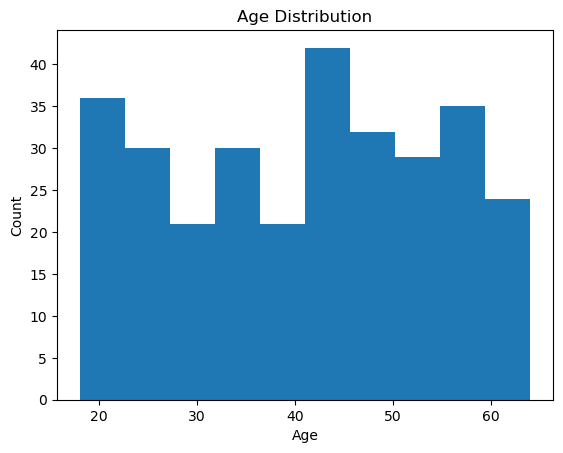

In [8]:
plt.hist(df['age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

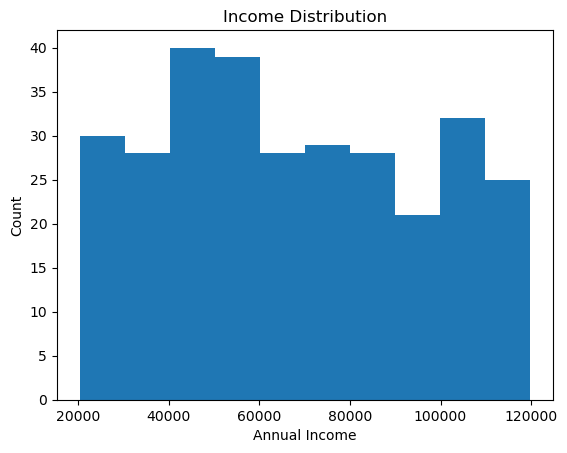

In [ ]:
plt.hist(df['annual_income'], bins=10)
plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

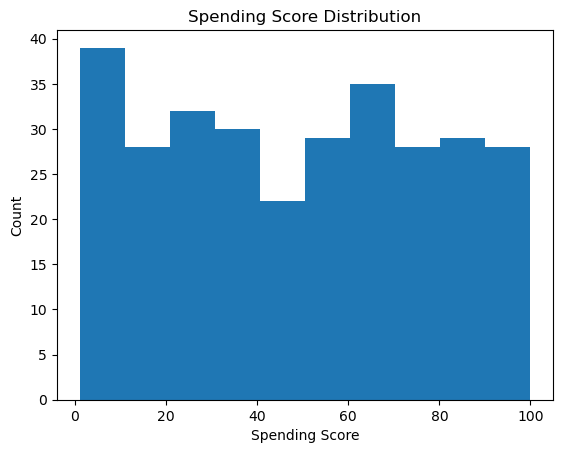

In [ ]:
plt.hist(df['spending_score'], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

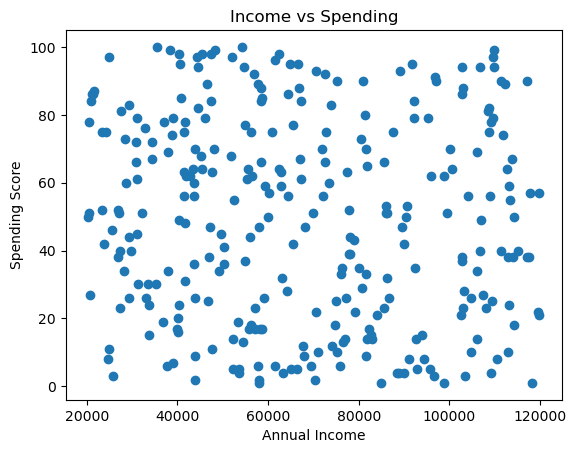

In [ ]:
plt.scatter(
    df['annual_income'],
    df['spending_score']
)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

In [12]:
X = df[['annual_income','spending_score']]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.77982392  0.26606003]
 [-0.32906708 -1.08335687]
 [ 0.77385827 -0.07129419]
 [ 1.2532386  -0.88094434]
 [ 1.48898026  1.00823933]]


In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

   customer_id  age  gender  annual_income  spending_score  total_purchases  \
0            1   56  Female         117856              57               25   
1            2   46    Male          58304              17               17   
2            3   32  Female          89449              47               66   
3            4   60    Male         102986              23               78   
4            5   25  Female         109643              79               53   

   Cluster  
0        1  
1        0  
2        1  
3        1  
4        1  


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


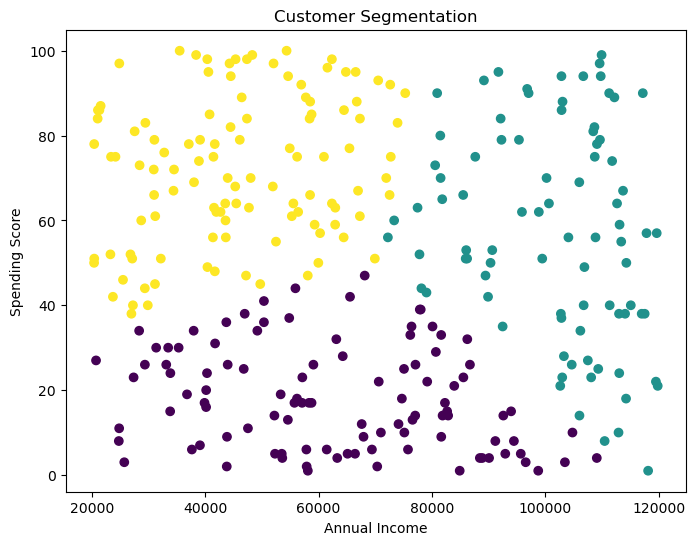

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['annual_income'],
    df['spending_score'],
    c=df['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [17]:
cluster_summary = df.groupby('Cluster').agg({
    'annual_income':'mean',
    'spending_score':'mean',
    'total_purchases':'mean'
})

print(cluster_summary)

         annual_income  spending_score  total_purchases
Cluster                                                
0         63053.163462       18.105769        39.615385
1        101525.376471       56.941176        36.705882
2         45871.405405       72.171171        40.315315
